In [2]:
#!pip install requests pandas matplotlib jiwer pillow

In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import requests
import pandas as pd
import re
from jiwer import wer, cer
import numpy as np

In [24]:
import json
import os
import time
import requests


JOB_URL = "https://paddleocr.aistudio-app.com/api/v2/ocr/jobs"

TOKEN = os.environ["PADDLEOCR_TOKEN"]

MODEL = "PaddleOCR-VL-1.5"


def run_ocr_one_image(image_path):

    headers = {
        "Authorization": f"bearer {TOKEN}"
    }

    data = {
        "model": MODEL,
        "optionalPayload": json.dumps({
            "useDocOrientationClassify": False,
            "useDocUnwarping": False,
            "useChartRecognition": False
        })
    }

    with open(image_path, "rb") as f:
        response = requests.post(
            JOB_URL,
            headers=headers,
            data=data,
            files={"file": f}
        )

    response.raise_for_status()

    job_id = response.json()["data"]["jobId"]

    while True:

        result_response = requests.get(
            f"{JOB_URL}/{job_id}",
            headers=headers
        )

        result_response.raise_for_status()

        result_data = result_response.json()["data"]
        state = result_data["state"]

        if state == "done":
            json_url = result_data["resultUrl"]["jsonUrl"]
            break

        if state == "failed":
            raise RuntimeError(
                result_data.get("errorMsg", "OCR job failed")
            )

        time.sleep(2)

    json_response = requests.get(json_url)
    json_response.raise_for_status()

    extracted_pages = []

    for line in json_response.text.splitlines():

        if not line.strip():
            continue

        obj = json.loads(line)

        results = obj["result"]["layoutParsingResults"]

        for page in results:

            blocks = page["prunedResult"]["parsing_res_list"]


            page_parts = []

            for block in blocks:

                label = block.get("block_label", "")
                content = block.get("block_content", "").strip()

                if not content:
                    continue

                if label in {
                    "number",
                    "header",
                    "paragraph_title",
                    "text"
                }:
                    page_parts.append(content)

            extracted_pages.append("\n".join(page_parts))

    return "\n\n".join(extracted_pages)

In [5]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

In [6]:
test_image_path = os.path.join( ENG_IMAGES_DIR, "1.jpg")

ocr_text = run_ocr_one_image(test_image_path)

print(ocr_text)

Uphill battle - Threats posed by AI to online privacy: Is there hope for having any control over one’s online data trail, when faced by even better AI profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The growing dependence on artificial intelligence has taken on an increasingly important role in the digital environment. Online activities such as browsing websites, using social media, and making online purchases generate large amounts of personal data. AI systems are able to analyse this data and create detailed profiles about individuals, often predicting their preferences, behaviour, or interests. These profiling practices are usually invisible to users, who may not be fully aware of how much data is collected 

In [8]:
import re
from jiwer import wer, cer
import unicodedata
import os

page = 1


def normalize_text(text):

    text = unicodedata.normalize("NFC", text)
    text = text.lower()

    text = re.sub(
        r"(\w)-[ \t]*\r?\n[ \t]*(\w)",
        r"\1\2",
        text
    )

    text = re.sub(r"\s+", " ", text)

    return text.strip()


gold_path = os.path.join(
    ENG_GOLD_DIR,
    f"{page}.txt"
)

with open(gold_path, "r", encoding="utf-8") as f:
    gold_text = f.read()


gold_norm = normalize_text(gold_text)
pred_norm = normalize_text(ocr_text)

wer_score = wer(gold_norm, pred_norm)
cer_score = cer(gold_norm, pred_norm)

print(f"Single Page Evaluation (Page {page})")
print(f"WER: {wer_score:.4f} ({wer_score * 100:.2f}%)")
print(f"CER: {cer_score:.4f} ({cer_score * 100:.2f}%)")

Single Page Evaluation (Page 1)
WER: 0.0734 (7.34%)
CER: 0.0626 (6.26%)


In [9]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

In [11]:
pages = [1,2,3,4,5,6]

In [25]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    output_path = os.path.join(
        output_dir,
        f"page_{p}.txt"
    )

    output_text = run_ocr_one_image(image_path)

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 1
Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Uphill battle - Threats posed by AI to online privacy: Is there hope for having any control over one’s online data trail, when faced by even better AI profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The growing dependence on artificial intelligence has taken on an increasingly important role in the digital environment. Online activities such as browsing websites, using social media, and making online purchases generate large amounts of personal data. AI systems are able to analyse this data and create detailed profiles about individuals, often predicting their preferences, behaviour, or interests. These profiling practices are usually in

In [50]:
def normalize_text(text):

    text = unicodedata.normalize("NFC", text)
    text = text.lower()

    #normalize apostrophes
    text = text.replace("’", "'")
    text = text.replace("‘", "'")
    text = text.replace("´", "'")
    text = text.replace("`", "'")

    #normalize quotation marks
    text = text.replace("“", '"')
    text = text.replace("”", '"')

    #join words split by line-ending hyphens
    text = re.sub(
        r"(\w)-[ \t]*\r?\n[ \t]*(\w)",
        r"\1\2",
        text
    )

    #normalize whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [51]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(
        ENG_GOLD_DIR,
        f"{p}.txt"
    )

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(
        output_dir,
        f"page_{p}.txt"
    )

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [52]:
print("=== Experiment 1 Results: PaddleOCR-VL-1.5 ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: PaddleOCR-VL-1.5 ===


,page,WER,CER
0,1,0.010127,0.007531
1,2,0.027350,0.015694
2,3,0.002179,0.000336
3,4,0.002299,0.000376
4,5,0.015306,0.001949
5,6,0.003035,0.000486


In [42]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 Results ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 Results ===
Mean WER: 0.0100
Mean CER: 0.0044


In [43]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

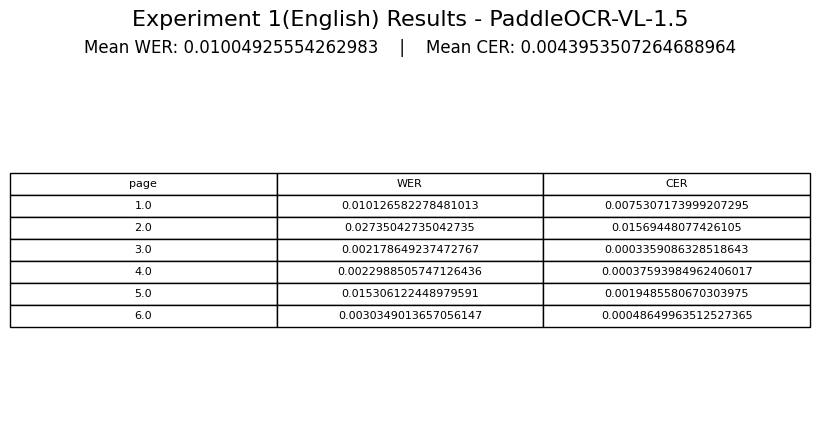

Saved: outputs/Results\experiment_1_results.png


In [44]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1(English) Results - PaddleOCR-VL-1.5", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)


table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

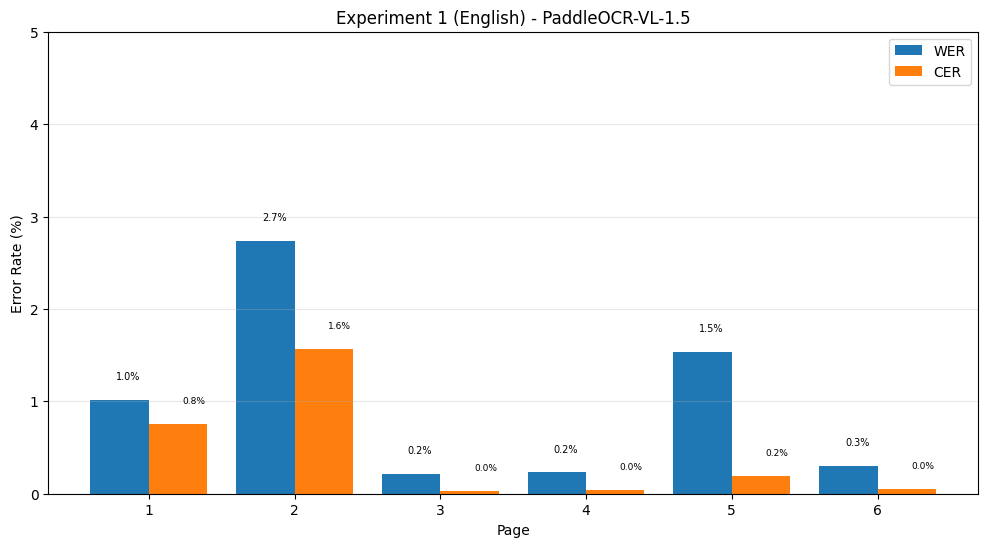

In [55]:
x = np.arange(len(df_exp1))
width = 0.40

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2, wer_pct, width, label="WER")
bars2 = plt.bar(x + width/2, cer_pct, width, label="CER")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2 + 0.06,
        bar.get_height() + 0.2,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=7
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2 + 0.11,
        bar.get_height() + 0.2,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        fontsize=6.5
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - PaddleOCR-VL-1.5")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 5)
plt.yticks(np.arange(0, 6, 1))

os.makedirs(output_dir_result_1, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_result_1,
        "experiment_1_paddleOCR_vl_English_wer_cer_by_page.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

In [49]:
page = 3

# Gold text
gold_path = os.path.join(
    ENG_GOLD_DIR,
    f"{page}.txt"
)

with open(gold_path, "r", encoding="utf-8") as f:
    gold_text = f.read()


# OCR output text
pred_path = os.path.join(
    output_dir,
    f"page_{page}.txt"
)

with open(pred_path, "r", encoding="utf-8") as f:
    pred_text = f.read()


# Normalize both
gold_norm = normalize_text(gold_text)
pred_norm = normalize_text(pred_text)


print("========== NORMALIZED GOLD TEXT ==========\n")
print(gold_norm)

print("\n\n========== NORMALIZED OCR OUTPUT ==========\n")
print(pred_norm)

========== NORMALIZED GOLD TEXT ==========

in may 2023, another incident happened again with ireland's data protection commission (dpc). the dpc fined meta €1.2 billion for mishandling the personal data of european users, marking the largest penalty ever under the eu's general data protection regulation (gdpr) [5]. the fine came after a long investigation into how the company transferred user data from the eu to the united states of america without adequate safeguards, despite a european court of justice ruling requiring strong protections for such transfers [5]. the dpc found that meta continued to send large volumes of facebook users' personal data to the usa on the basis of standard contractual clauses (sccs) that did not sufficiently protect individuals' privacy rights, exposing that data to potential access by us intelligence agencies. because these clauses failed to meet gdpr standards, the regulator concluded that meta was in breach of article 46(1) of the gdpr [18], which gove